# Stage 01 — Baseline τ search (no ML)

Bayesian optimisation over the 6-dim maintenance interval vector $(\tau_{C1}, \dots, \tau_{C6})$ using Optuna. Each trial runs the deterministic SDG simulator on a stratified subset of printers (one per city) and scores them with the penalised cost / availability objective from `ml_models.lib.objective`.

Top-K trials are re-evaluated on the **full 100-printer fleet** for the final leaderboard. The winner is saved to `results/best_tau.yaml`.

**Tip:** the Optuna study is persisted to a local SQLite file (`results/study.db`), so this notebook is resumable: re-running the search cell continues the same study.

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import yaml

from ml_models.lib.env_runner import default_dates, run_with_tau
from ml_models.lib.objective import scalar_objective
from ml_models.lib.plotting import plot_pareto_cost_availability
from sdg.generate import build_printer_city_map, load_configs
from sdg.schema import COMPONENT_IDS

RESULTS_DIR = Path('ml_models/01_baseline/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
STUDY_PATH = RESULTS_DIR / 'study.db'
BEST_TAU_PATH = RESULTS_DIR / 'best_tau.yaml'

print('Optuna version:', optuna.__version__)
print('Components:', COMPONENT_IDS)

Optuna version: 4.8.0
Components: ('C1', 'C2', 'C3', 'C4', 'C5', 'C6')


## Search space and printer subset

Per-component log-uniform priors anchored on `digital_twin_hp_metal_jet_s100_spec.md` §6 (operative ranges of $\tau_{nom}$). The trial subset uses one printer per city so each trial costs roughly 15× one-printer simulations — cheap enough for hundreds of trials, diverse enough to capture climate effects.

In [2]:
TAU_RANGES = {
    'C1': (50.0, 2_000.0),
    'C2': (500.0, 20_000.0),
    'C3': (24.0, 500.0),
    'C4': (100.0, 2_000.0),
    'C5': (500.0, 8_000.0),
    'C6': (1_000.0, 20_000.0),
}

components_cfg, couplings_cfg, cities_cfg = load_configs()
printer_city_map = build_printer_city_map(list(cities_cfg['cities']))

seen: set[str] = set()
TRIAL_PRINTER_IDS: list[int] = []
for printer_id, profile in enumerate(printer_city_map):
    name = profile['name']
    if name not in seen:
        seen.add(name)
        TRIAL_PRINTER_IDS.append(printer_id)
DATES = default_dates()

print('Stratified printers (one per city):', TRIAL_PRINTER_IDS)
print('Days per printer:', len(DATES))

Stratified printers (one per city): [0, 7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 76, 82, 88, 94]
Days per printer: 3653


In [3]:
def trial_to_tau(trial: optuna.Trial) -> dict[str, float]:
    return {
        component_id: trial.suggest_float(f'tau_{component_id}', low, high, log=True)
        for component_id, (low, high) in TAU_RANGES.items()
    }


def objective(trial: optuna.Trial) -> float:
    tau_vector = trial_to_tau(trial)
    events = run_with_tau(
        tau_vector,
        printer_ids=TRIAL_PRINTER_IDS,
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    for key in ('annual_cost', 'availability', 'preventive_cost', 'corrective_cost', 'deficit'):
        trial.set_user_attr(key, float(score[key]))
    return float(score['value'])

## Run the study

TPE sampler with a fixed seed for reproducibility, MedianPruner kills weak trials early. The study is persisted to SQLite so the cell is **resumable**: re-running it continues from where it left off.

Set `N_TRIALS` to ~30 for a smoke run; ~200–500 for a serious search.

In [4]:
N_TRIALS = 200
storage_url = f'sqlite:///{STUDY_PATH.as_posix()}'
study = optuna.create_study(
    study_name='baseline_tau',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    storage=storage_url,
    load_if_exists=True,
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print('Best value:', study.best_value)
print('Best params:', study.best_params)
print('Best user_attrs:', study.best_trial.user_attrs)

[I 2026-04-25 06:16:54,468] Using an existing study with name 'baseline_tau' instead of creating a new one.


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-25 06:16:55,770] Trial 200 finished with value: 5693643.419411747 and parameters: {'tau_C1': 1716.8501573110568, 'tau_C2': 774.5908465766779, 'tau_C3': 497.5609577067049, 'tau_C4': 1632.817699779017, 'tau_C5': 3446.8535263211284, 'tau_C6': 3941.198879019171}. Best is trial 185 with value: 5676258.859080817.
[I 2026-04-25 06:16:57,004] Trial 201 finished with value: 5695999.796970527 and parameters: {'tau_C1': 1872.495055128822, 'tau_C2': 705.2563690461744, 'tau_C3': 470.4924322319002, 'tau_C4': 1776.5701442503803, 'tau_C5': 3992.5097977679197, 'tau_C6': 5160.238116745664}. Best is trial 185 with value: 5676258.859080817.
[I 2026-04-25 06:16:58,207] Trial 202 finished with value: 5678195.103415762 and parameters: {'tau_C1': 1729.045539956283, 'tau_C2': 626.5296150410684, 'tau_C3': 499.159995299079, 'tau_C4': 1822.816519352254, 'tau_C5': 4258.3954512058, 'tau_C6': 4662.308077843427}. Best is trial 185 with value: 5676258.859080817.
[I 2026-04-25 06:16:59,480] Trial 203 finishe

In [5]:
trials_df = study.trials_dataframe()
trials_df = trials_df.dropna(subset=['value']).sort_values('value').reset_index(drop=True)
display_cols = ['number', 'value', 'user_attrs_annual_cost', 'user_attrs_availability']
display_cols += [f'params_tau_{component_id}' for component_id in COMPONENT_IDS]
trials_df.loc[:9, display_cols].round(3)

,number,value,user_attrs_annual_cost,user_attrs_availability,params_tau_C1,params_tau_C2,params_tau_C3,params_tau_C4,params_tau_C5,params_tau_C6
0,343,5671342.953,4512274.303,-0.209,1990.446,538.315,499.992,1913.417,4368.405,5408.122
1,308,5672064.765,4512634.921,-0.209,1696.620,538.195,498.732,1999.809,3738.920,5395.530
2,347,5672182.438,4512738.906,-0.209,1989.652,568.840,498.785,1872.624,3905.082,5662.209
3,322,5672931.332,4513355.489,-0.210,1872.291,533.706,499.869,1812.060,4230.072,4709.614
4,341,5673124.897,4513325.493,-0.210,1723.040,559.076,499.661,1893.249,4381.681,5614.308
5,204,5674374.672,4514181.376,-0.210,1852.533,557.049,498.498,1812.097,3583.519,4943.364
6,238,5674617.464,4515135.912,-0.209,1664.735,500.645,499.702,1692.534,3719.241,4108.534
7,363,5675130.719,4515384.544,-0.210,1822.008,544.949,498.759,1690.879,3720.676,6239.447
8,372,5675489.009,4514886.612,-0.211,1769.568,611.979,499.648,1790.370,4243.750,4633.018
9,337,5675549.919,4515345.216,-0.210,1873.390,565.685,499.434,1730.639,4291.627,5715.680


## Re-evaluate top trials on the full 100-printer fleet

The trial subset of 15 printers is fast but biased; re-evaluating the top-K candidates on all 100 printers gives an unbiased final ranking.

In [6]:
TOP_K = 5
fleet_results = []
for _, row in trials_df.head(TOP_K).iterrows():
    tau_vector = {
        component_id: float(row[f'params_tau_{component_id}'])
        for component_id in COMPONENT_IDS
    }
    events = run_with_tau(
        tau_vector,
        printer_ids=range(100),
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    fleet_results.append(
        {
            'trial': int(row['number']),
            'value': float(score['value']),
            'annual_cost': float(score['annual_cost']),
            'availability': float(score['availability']),
            'preventive_cost': float(score['preventive_cost']),
            'corrective_cost': float(score['corrective_cost']),
            **{f'tau_{c}': tau_vector[c] for c in COMPONENT_IDS},
        }
    )
fleet_df = pd.DataFrame(fleet_results).sort_values('value').reset_index(drop=True)
fleet_df

,trial,value,annual_cost,availability,preventive_cost,corrective_cost,tau_C1,tau_C2,tau_C3,tau_C4,tau_C5,tau_C6
0,343,5.548033e+06,4.417249e+06,-0.180784,10121.014509,4.407128e+06,1990.446468,538.315246,499.992063,1913.416972,4368.405175,5408.121820
1,308,5.548567e+06,4.417484e+06,-0.181083,10436.471325,4.407048e+06,1696.619771,538.194878,498.732341,1999.809342,3738.920099,5395.530127
2,347,5.549636e+06,4.418467e+06,-0.181169,9913.542910,4.408553e+06,1989.651911,568.840022,498.785409,1872.623687,3905.082158,5662.208504
3,341,5.550287e+06,4.418871e+06,-0.181416,9680.374829,4.409190e+06,1723.040486,559.076039,499.661278,1893.248670,4381.680794,5614.308095
4,322,5.552356e+06,4.420619e+06,-0.181737,10539.557213,4.410080e+06,1872.291132,533.706459,499.869497,1812.060060,4230.072247,4709.614055


In [7]:
winner = fleet_df.iloc[0]
best_tau = {component_id: float(winner[f'tau_{component_id}']) for component_id in COMPONENT_IDS}
payload = {
    'tau_nom_h': best_tau,
    'validated_on': 'full fleet (printer_id 0..99)',
    'penalised_value': float(winner['value']),
    'annual_cost_eur_per_printer_year': float(winner['annual_cost']),
    'availability': float(winner['availability']),
    'preventive_cost_eur_per_printer_year': float(winner['preventive_cost']),
    'corrective_cost_eur_per_printer_year': float(winner['corrective_cost']),
}
with BEST_TAU_PATH.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(payload, handle, sort_keys=False)
print('Wrote:', BEST_TAU_PATH)
print(yaml.safe_dump(payload, sort_keys=False))

Wrote: ml_models/01_baseline/results/best_tau.yaml
tau_nom_h:
  C1: 1990.4464682135354
  C2: 538.3152458707128
  C3: 499.9920631435765
  C4: 1913.4169717676903
  C5: 4368.4051751059405
  C6: 5408.121819647594
validated_on: full fleet (printer_id 0..99)
penalised_value: 5548032.928118442
annual_cost_eur_per_printer_year: 4417249.211538462
availability: -0.18078371657997994
preventive_cost_eur_per_printer_year: 10121.01450862305
corrective_cost_eur_per_printer_year: 4407128.197029838



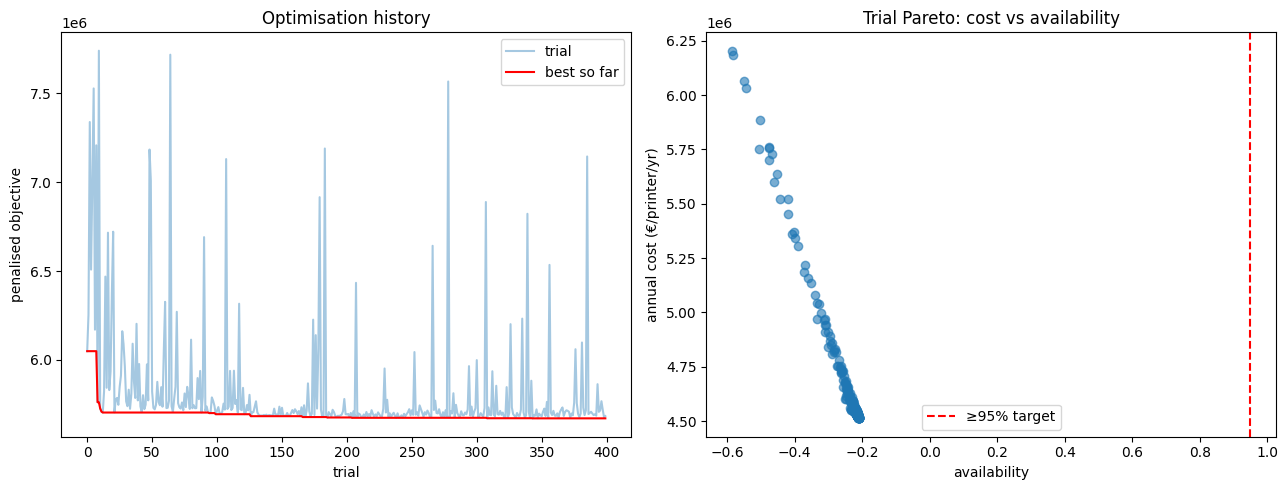

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
history = study.trials_dataframe().dropna(subset=['value'])
axes[0].plot(history['number'], history['value'], alpha=0.4, label='trial')
axes[0].plot(history['number'], history['value'].cummin(), color='red', label='best so far')
axes[0].set_xlabel('trial')
axes[0].set_ylabel('penalised objective')
axes[0].set_title('Optimisation history')
axes[0].legend()

study_df = study.trials_dataframe().dropna(subset=['user_attrs_annual_cost', 'user_attrs_availability'])
study_df = study_df.rename(columns={
    'user_attrs_annual_cost': 'annual_cost',
    'user_attrs_availability': 'availability',
})
plot_pareto_cost_availability(study_df, ax=axes[1])
axes[1].set_title('Trial Pareto: cost vs availability')
plt.tight_layout()
plt.show()

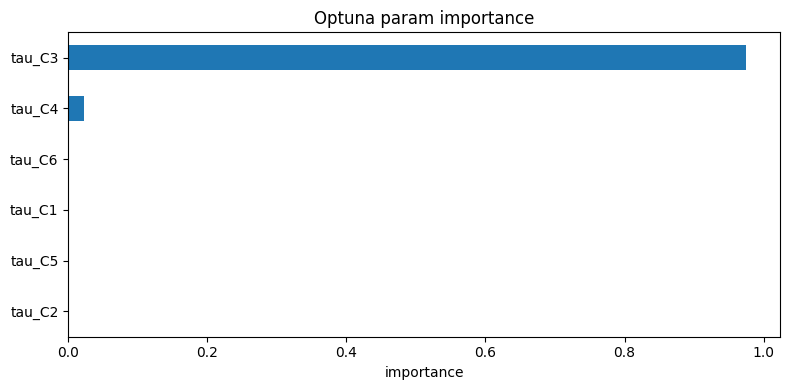

In [9]:
try:
    importance = optuna.importance.get_param_importances(study)
    pd.Series(importance).sort_values().plot(kind='barh', figsize=(8, 4), title='Optuna param importance')
    plt.xlabel('importance')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Importance unavailable:', exc)